In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df=sns.load_dataset("glue")

In [5]:
df.head()

,Model,Year,Encoder,Task,Score
0,ERNIE,2019,Transformer,CoLA,75.5
1,T5,2019,Transformer,CoLA,71.6
2,RoBERTa,2019,Transformer,CoLA,67.8
3,BERT,2018,Transformer,CoLA,60.5
4,BiLSTM+ELMo,2018,LSTM,CoLA,32.1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Model    64 non-null     str    
 1   Year     64 non-null     int64  
 2   Encoder  64 non-null     str    
 3   Task     64 non-null     str    
 4   Score    64 non-null     float64
dtypes: float64(1), int64(1), str(3)
memory usage: 3.8 KB


In [7]:
for i in df:
    print(df[i].value_counts())

Model
ERNIE          8
T5             8
RoBERTa        8
BERT           8
BiLSTM+ELMo    8
BiLSTM+CoVe    8
BiLSTM+Attn    8
BiLSTM         8
Name: count, dtype: int64
Year
2019    24
2017    24
2018    16
Name: count, dtype: int64
Encoder
Transformer    32
LSTM           32
Name: count, dtype: int64
Task
CoLA     8
SST-2    8
MRPC     8
STS-B    8
QQP      8
MNLI     8
QNLI     8
RTE      8
Name: count, dtype: int64
Score
75.5    2
89.3    2
92.8    2
92.3    2
92.2    2
70.3    2
74.3    2
57.4    2
71.6    1
67.8    1
60.5    1
32.1    1
18.5    1
18.6    1
11.6    1
97.8    1
97.5    1
96.7    1
94.9    1
81.9    1
83.0    1
82.8    1
93.9    1
84.7    1
78.7    1
83.9    1
81.8    1
93.0    1
93.1    1
87.6    1
64.4    1
72.8    1
75.2    1
75.1    1
72.1    1
61.1    1
60.6    1
60.1    1
62.5    1
90.8    1
86.7    1
67.2    1
65.4    1
67.6    1
65.6    1
97.3    1
96.9    1
95.4    1
92.7    1
70.8    1
74.6    1
92.6    1
88.2    1
70.1    1
52.7    1
58.4    1
Name: count, 

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le=LabelEncoder()

In [10]:
df["Model"]=le.fit_transform(df["Model"])
df["Encoder"]=le.fit_transform(df["Encoder"])
df["Task"]=le.fit_transform(df["Task"])


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
# sc=StandardScaler()
# features=sc.fit_transform

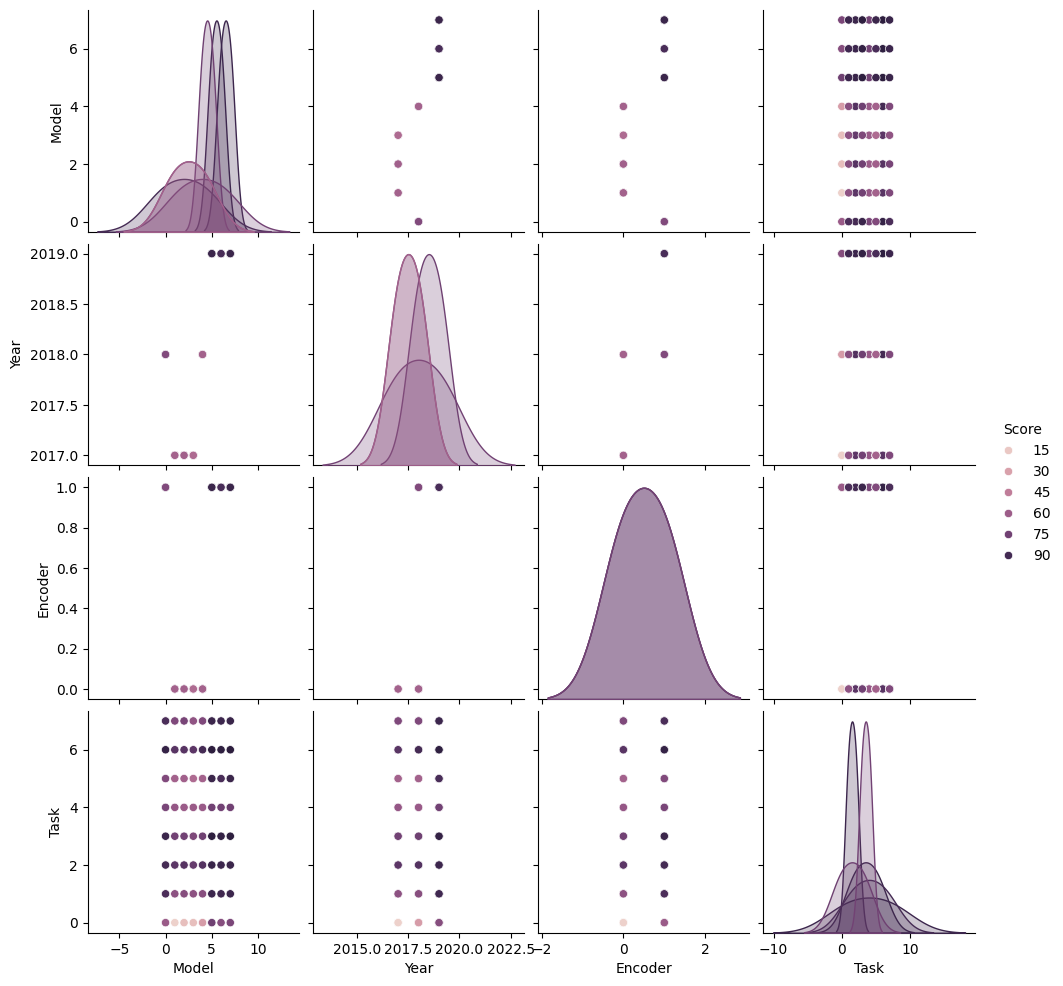

In [13]:
sns.pairplot(df,hue="Score")

<Axes: >

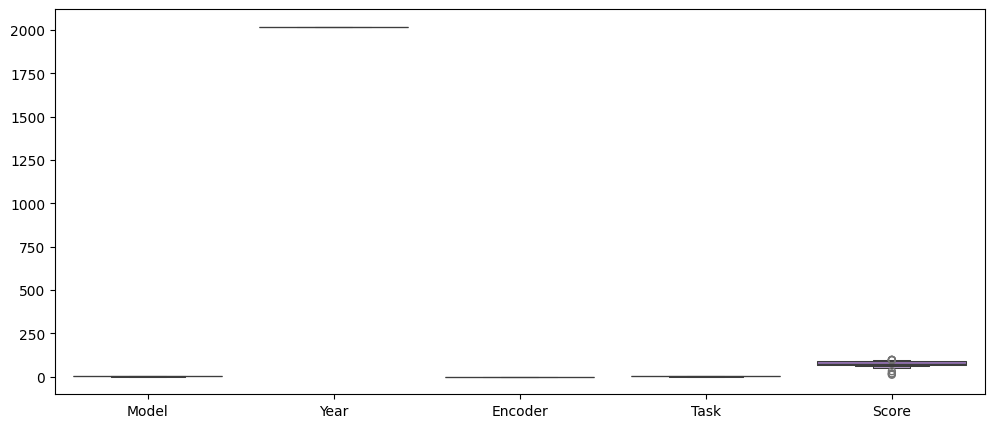

In [14]:
plt.figure(figsize=(12,5))
sns.boxenplot(df)

In [15]:
df=df.drop("Score",axis=1)

In [16]:
# scc=StandardScaler()
# df=scc.fit_transform(df)

In [17]:
import scipy.cluster.hierarchy as sc


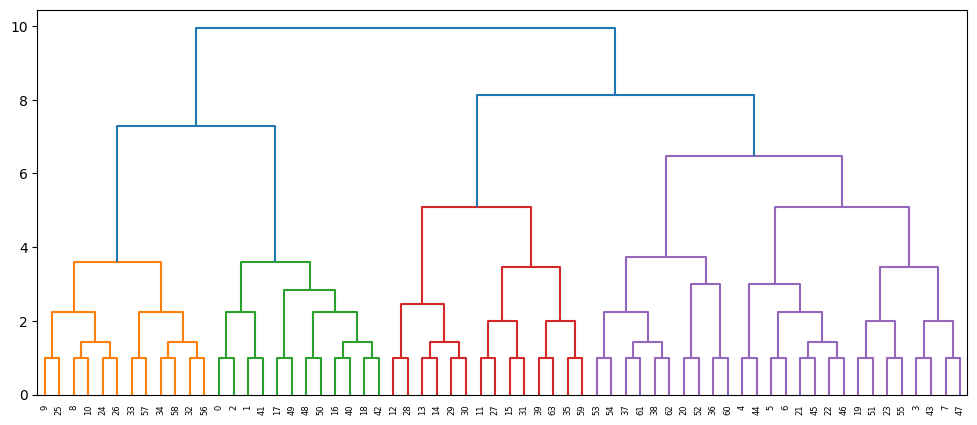

In [18]:
plt.figure(figsize=(12,5))
sc.dendrogram(sc.linkage(df,method="complete",metric="euclidean"))
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering

In [20]:
ac=AgglomerativeClustering(n_clusters=6,linkage="complete")

In [21]:
df["predict_score"]=ac.fit_predict(df)

In [22]:
df.head()

,Model,Year,Encoder,Task,predict_score
0,5,2019,1,0,4
1,7,2019,1,0,4
2,6,2019,1,0,4
3,0,2018,1,0,2
4,4,2018,0,0,5


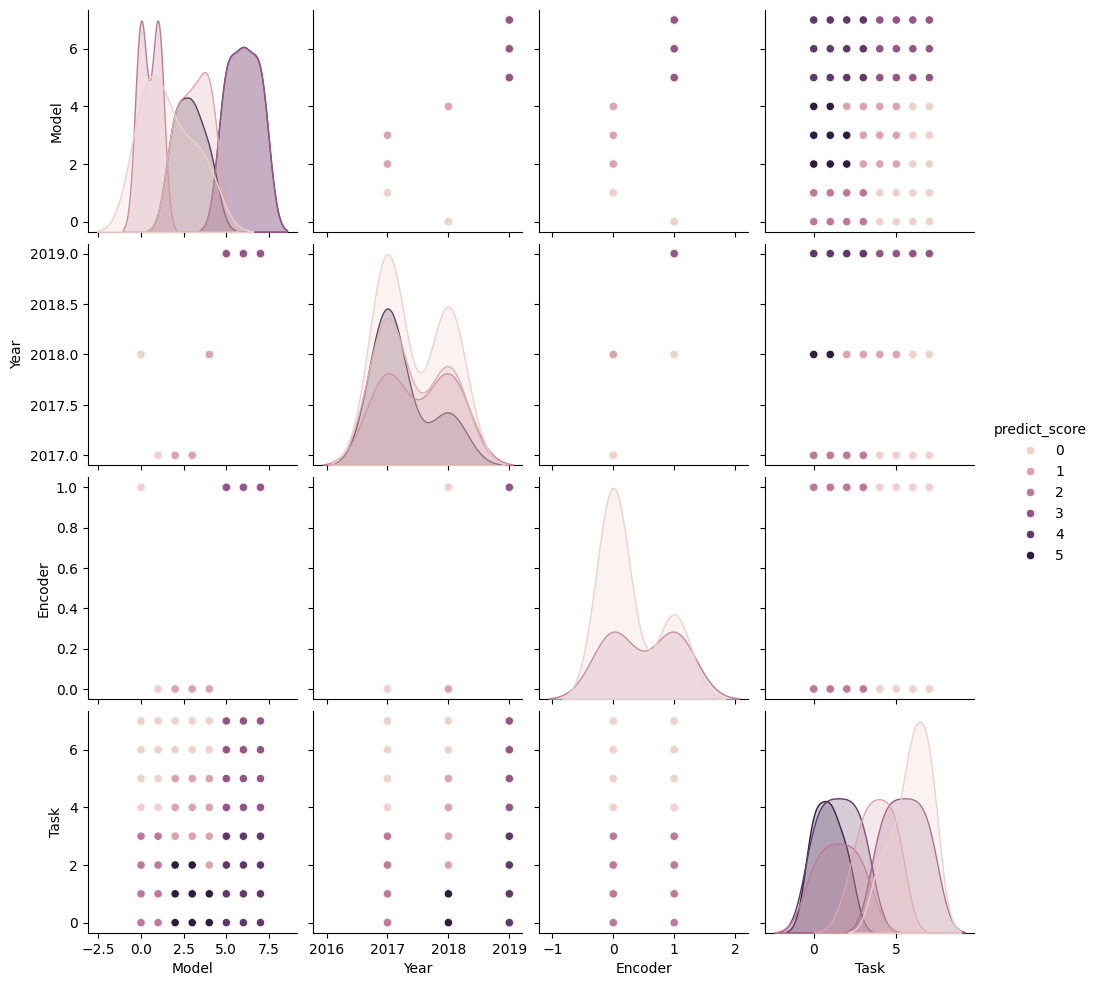

In [23]:
sns.pairplot(df,hue="predict_score")

In [24]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df, ac.labels_)*100
print(score)

42.448881290426876


In [25]:
from sklearn.cluster import BisectingKMeans
df=df.drop("predict_score",axis=1)

In [26]:
bm=BisectingKMeans(n_clusters=4,random_state=42)

In [27]:
df["bisecting_predict"]=bm.fit_predict(df)

In [28]:
from sklearn.metrics import silhouette_score

In [29]:
score=silhouette_score(df,bm.labels_)

In [30]:
score

0.43490606800785825

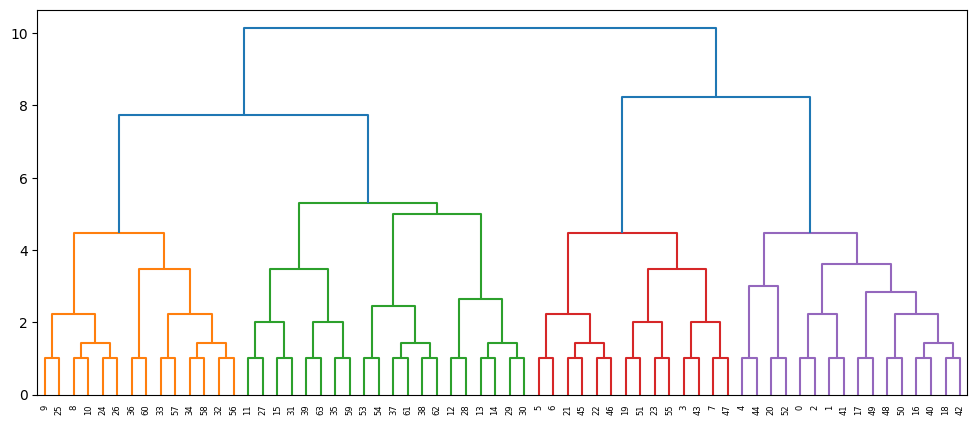

In [31]:
plt.figure(figsize=(12,5))
sc.dendrogram(sc.linkage(df,method="complete",metric="euclidean"))
plt.show()

In [32]:
df.head(40)

,Model,Year,Encoder,Task,bisecting_predict
0,5,2019,1,0,3
1,7,2019,1,0,3
2,6,2019,1,0,3
3,0,2018,1,0,0
4,4,2018,0,0,3
5,3,2017,0,0,0
6,2,2017,0,0,0
7,1,2017,0,0,0
8,5,2019,1,6,2
9,7,2019,1,6,2
